# Статистический анализ бинарных файлов в целях обнаружения  malware

## Portable Executable (PE) Format и модуль `pefile`

### 1. Что такое PE-формат?

Portable Executable (PE) — это спецификация двоичного формата исполняемых файлов, используемая в операционных системах Windows. Он применяется для:

- `.exe` (исполняемые файлы)
- `.dll` (динамические библиотеки (драйверы устройств)
- `.scr` (скринсейверы)

Формат PE основан на более старом формате COFF (Common Object File Format) и включает:

- Заголовки (DOS, PE, опциональный заголовок)
- Таблицу импорта (Import Table)
- Таблицу экспорта (Export Table)
- Разделы (sections), такие как `.text`, `.data`, `.rsrc` и т.д.
- Информацию о зависимостях, символах и отладке

> ![PE формат](https://0xrick.github.io/images/wininternals/pe2/1.png)
---

### 2. Модуль `pefile`

Модуль `pefile` — это популярная библиотека на Python, позволяющая анализировать PE-файлы. Она предоставляет удобный интерфейс для чтения и анализа структур данных внутри исполняемых файлов.

#### Установка:
```bash
pip install pefile
```

#### Основные атрибуты объекта `pe`:

- `pe.FILE_HEADER` — заголовок файла (например, архитектура, количество секций).
- `pe.OPTIONAL_HEADER` — опциональный заголовок (адрес точки входа, субсистема и т.д.).
- `pe.sections` — список секций.
- `pe.DIRECTORY_ENTRY_IMPORT` — таблица импорта.
- `pe.DIRECTORY_ENTRY_EXPORT` — таблица экспорта.

#### Полезные методы:

- `pe.write()` — позволяет получить байты PE-файла.
- `pe.get_data(start, length)` — извлекает данные из образа.
- `pe.has_entry_point()` — проверяет, есть ли точка входа.
- `pe.parse_data_directories()` — позволяет вручную указать, какие директории анализировать.

In [1]:
!pip install pefile pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 950.4 kB/s eta 0:00:00


In [2]:
!wget https://the.earth.li/~sgtatham/putty/latest/w64/putty.exe

--2026-04-29 09:30:19--  https://the.earth.li/~sgtatham/putty/latest/w64/putty.exe
Resolving the.earth.li (the.earth.li)... 93.93.131.124, 2a00:1098:86:4d:c0ff:ee:15:900d
Connecting to the.earth.li (the.earth.li)|93.93.131.124|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://the.earth.li/~sgtatham/putty/0.83/w64/putty.exe [following]
--2026-04-29 09:30:20--  https://the.earth.li/~sgtatham/putty/0.83/w64/putty.exe
Reusing existing connection to the.earth.li:443.
HTTP request sent, awaiting response... 200 OK
Length: 1709672 (1.6M) [application/x-msdos-program]
Saving to: ‘putty.exe’

putty.exe           100%[===================>]   1.63M  1.28MB/s    in 1.3s    

2026-04-29 09:30:21 (1.28 MB/s) - ‘putty.exe’ saved [1709672/1709672]



In [3]:
# Открываем PE-файл
import pefile
filename = 'putty.exe'
pe =  pefile.PE(filename)

In [4]:
print(type(pe))
print(pe.OPTIONAL_HEADER.AddressOfEntryPoint)
print(pe.OPTIONAL_HEADER.ImageBase)
print(pe.FILE_HEADER.NumberOfSections)

<class 'pefile.PE'>
779524
5368709120
10


In [5]:
# Выводим разделы
for section in pe.sections:
  print(section.Name, hex(section.VirtualAddress),
    hex(section.Misc_VirtualSize), section.SizeOfRawData )

b'.text\x00\x00\x00' 0x1000 0xebc26 966144
b'.rdata\x00\x00' 0xed000 0x4464c 280576
b'.data\x00\x00\x00' 0x132000 0x41fc 4096
b'.pdata\x00\x00' 0x137000 0x70f8 29184
b'.00cfg\x00\x00' 0x13f000 0x38 512
b'.gxfg\x00\x00\x00' 0x140000 0x2ae0 11264
b'.tls\x00\x00\x00\x00' 0x143000 0x11 512
b'_RDATA\x00\x00' 0x144000 0x15c 512
b'.rsrc\x00\x00\x00' 0x145000 0x5ce10 380928
b'.reloc\x00\x00' 0x1a2000 0x21b8 8704


### Формирование признаков

https://arxiv.org/abs/1804.04637

## Энтропия последовательности байтов

### Формула энтропии Шеннона

Для вычисления энтропии последовательности байтов используется **энтропия Шеннона**, которая измеряет степень неопределенности или "случайность" данных. Формула следующая:

$$
H(X) = -\sum_{i=0}^{N} P(x_i) \cdot Log_2(P(x_i))
$$

где:
- $ x_i $ — уникальный байт (значение от 0 до 255),
- $ P(x_i) $ — **относительная частота** появления байта $ x_i $,
- $ N $ — количество уникальных байтов в последовательности,
- $ Log_2 $ — логарифм по основанию 2 (для получения результата в **битах**).

---

### Как вычислить $ P(x_i) $

$$
P(x_i) = \frac{\text{количество вхождений } x_i}{\text{общее количество байтов}}
$$

То есть, если в файле 1000 байтов и байт `0xFF` встречается 100 раз, то:

$$
P(0xFF) = \frac{100}{1000} = 0.1
$$

---



In [6]:
import array
import math
from typing import Union, Sequence

def get_entropy(data: Union[bytes, str, Sequence[int]]) -> float:
    """
    Вычисляет энтропию Шеннона для последовательности байт/символов.

    Args:
        data: Входные данные (bytes, str или последовательность int 0-255)

    Returns:
        float: Значение энтропии в битах (0-8 для байтов)
    """
    if len(data) == 0:
        return 0.0
    occurences = array.array('L', [0]*256)
    for x in data:
        occurences[x if isinstance(x, int) else ord(x)] += 1

    entropy = 0.0
    # TODO compute entropy
    total = len(data)
    for count in occurences:
        if count > 0:
            p = count / total
            entropy -= p * math.log2(p)

    return entropy

In [7]:
# Тесты с подробными сообщениями об ошибках на русском языке

# 1. Тест пустых данных
result = get_entropy(b"")
assert result == 0.0, f"ОШИБКА: Энтропия пустых данных должна быть 0.0, получено {result}"

# 2. Тест однородных данных (все байты одинаковые) - энтропия должна быть 0
uniform_data = b"AAAAA"
result = get_entropy(uniform_data)
assert result == 0.0, f"ОШИБКА: Энтропия однородных данных должна быть 0.0, получено {result}"

# 3. Тест равномерного распределения (все байты разные с равной частотой)
# Для 256 различных байтов с равной частотой энтропия = log2(256) = 8
uniform_dist = bytes(range(256))
result = get_entropy(uniform_dist)
assert abs(result - 8.0) < 0.0001, f"ОШИБКА: Энтропия равномерного распределения 256 байт должна быть 8.0, получено {result}"

# 4. Тест данных с двумя равновероятными символами
# Энтропия = -0.5*log2(0.5) - 0.5*log2(0.5) = 1
two_sym = b"ABABABAB"
result = get_entropy(two_sym)
assert abs(result - 1.0) < 0.0001, f"ОШИБКА: Энтропия двух равновероятных символов должна быть 1.0, получено {result}"
# 5. Тест строки (str) вместо bytes
result_str = get_entropy("AAAAA")
assert result_str == 0.0, f"ОШИБКА: Энтропия однородной строки должна быть 0.0, получено {result_str}"

# 6. Тест строки с разными символами
result_str2 = get_entropy("ABABAB")
assert abs(result_str2 - 1.0) < 0.0001, f"ОШИБКА: Энтропия строки 'ABABAB' должна быть 1.0, получено {result_str2}"

# 7. Тест списка целых чисел
result_list = get_entropy([65, 65, 65])
assert result_list == 0.0, f"ОШИБКА: Энтропия списка одинаковых чисел должна быть 0.0, получено {result_list}"

# 8. Тест смешанных значений (разные частоты)
# Для 'AAAAB' (4/5 и 1/5): энтропия = -0.8*log2(0.8) - 0.2*log2(0.2) ≈ 0.7219
mixed = b"AAAAB"
result = get_entropy(mixed)
expected = -0.8 * math.log(0.8, 2) - 0.2 * math.log(0.2, 2)
assert abs(result - expected) < 0.0001, f"ОШИБКА: Энтропия 'AAAAB' должна быть ~{expected:.4f}, получено {result}"

# 9. Тест больших данных (производительность/корректность)
large_uniform = b"A" * 1000000 + b"B" * 1000000
result_large = get_entropy(large_uniform)
assert abs(result_large - 1.0) < 0.0001, f"ОШИБКА: Энтропия большого набора с двумя равными группами должна быть 1.0, получено {result_large}"

# 10. Тест на возвращаемый тип
result_type = get_entropy(b"test")
assert isinstance(result_type, float), f"ОШИБКА: Функция должна возвращать float, получен тип {type(result_type)}"

# 11. Тест с байтом 0 (нулевой байт)
null_data = bytes([0, 0, 0])
result_null = get_entropy(null_data)
assert result_null == 0.0, f"ОШИБКА: Энтропия нулевых байтов должна быть 0.0, получено {result_null}"

# 12. Тест с максимальным байтом (255)
max_byte_data = bytes([255, 255, 255])
result_max = get_entropy(max_byte_data)
assert result_max == 0.0, f"ОШИБКА: Энтропия байтов 255 должна быть 0.0, получено {result_max}"

# 13. Тест с диапазоном байтов 0-255
full_range = bytes(range(256)) * 2  # Каждый байт встречается 2 раза
result_full = get_entropy(full_range)
assert abs(result_full - 8.0) < 0.0001, f"ОШИБКА: Энтропия полного диапазона байтов должна быть 8.0, получено {result_full}"

# 14. Тест корректности при одном элементе
single = b"X"
result_single = get_entropy(single)
assert result_single == 0.0, f"ОШИБКА: Энтропия одного элемента должна быть 0.0, получено {result_single}"

print("Все тесты пройдены успешно!")

Все тесты пройдены успешно!


In [8]:
!wget https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/PE_main.py
from PE_main import extract_infos
print(extract_infos(filename, get_entropy=get_entropy))

--2026-04-29 09:38:07--  https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/PE_main.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7135 (7.0K) [text/plain]
Saving to: ‘PE_main.py’

PE_main.py          100%[===================>]   6.97K  --.-KB/s    in 0s      

2026-04-29 09:38:07 (76.4 MB/s) - ‘PE_main.py’ saved [7135/7135]

{'Machine': 34404, 'SizeOfOptionalHeader': 240, 'Characteristics': 34, 'MajorLinkerVersion': 14, 'MinorLinkerVersion': 0, 'SizeOfCode': 966144, 'SizeOfInitializedData': 716288, 'SizeOfUninitializedData': 0, 'AddressOfEntryPoint': 779524, 'BaseOfCode': 4096, 'BaseOfData': 0, 'ImageBase': 5368709120, 'SectionAlignment': 4096, 'FileAlignment': 512, 'MajorOperatingSystemVersion': 6, 'MinorOp

## Информация о выборке данных

## Библиотека Pandas

Pandas — это мощная библиотека языка Python, предназначенная для анализа и обработки табличных данных. Она предоставляет удобные и эффективные структуры данных, такие как `DataFrame` и `Series`, а также широкий набор методов для манипуляций с данными, очистки, агрегации, объединения и визуализации.

### Основные возможности:

- **DataFrame** — двумерная таблица с индексами по строкам и столбцам, аналогична таблице в Excel или SQL.
- **Series** — одномерный массив с метками, представляющий собой один столбец DataFrame.
- **Загрузка и сохранение данных** из различных форматов: CSV, Excel, JSON, SQL, HDF5, Parquet и другие.
- **Группировка, фильтрация, агрегация** данных.
- **Обработка пропущенных значений** (`NaN`).
- **Объединение и слияние** наборов данных (аналог JOIN в SQL).
- **Работа с временными рядами** (Time Series Analysis).
- **Интеграция с NumPy и Matplotlib**.


In [9]:
!wget https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/data.csv

--2026-04-29 09:38:59--  https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50668563 (48M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]  48.32M  79.5MB/s    in 0.6s    

2026-04-29 09:39:02 (79.5 MB/s) - ‘data.csv’ saved [50668563/50668563]



In [10]:

import pandas as pd # библиотека для работы с данными
dataset = pd.read_csv('data.csv', sep='|')

In [11]:
dataset.head()    #Вывод первых 5 строчек кода

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
0,memtest.exe,631ea355665f28d4707448e442fbf5b8,332,224,258,9,0,361984,115712,0,...,4,3.262823,2.568844,3.537939,8797.000000,216,18032,0,16,1
1,ose.exe,9d10f99a6712e28f8acd5641e3a7ea6b,332,224,3330,9,0,130560,19968,0,...,2,4.250461,3.420744,5.080177,837.000000,518,1156,72,18,1
2,setup.exe,4d92f518527353c0db88a70fddcfd390,332,224,3330,9,0,517120,621568,0,...,11,4.426324,2.846449,5.271813,31102.272727,104,270376,72,18,1
3,DW20.EXE,a41e524f8d45f0074fd07805ff0c9b12,332,224,258,9,0,585728,369152,0,...,10,4.364291,2.669314,6.400720,1457.000000,90,4264,72,18,1
4,dwtrig20.exe,c87e561258f2f8650cef999bf643a731,332,224,258,9,0,294912,247296,0,...,2,4.306100,3.421598,5.190603,1074.500000,849,1300,72,18,1


In [12]:
dataset.tail()     # Вывод последних 5 строчек кода

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
138042,VirusShare_8e292b418568d6e7b87f2a32aee7074b,8e292b418568d6e7b87f2a32aee7074b,332,224,258,11,0,205824,223744,0,...,7,4.122736,1.370260,7.677091,14900.714286,16,81654,72,0,0
138043,VirusShare_260d9e2258aed4c8a3bbd703ec895822,260d9e2258aed4c8a3bbd703ec895822,332,224,33167,2,25,37888,185344,0,...,26,3.377663,2.031619,5.050074,6905.846154,44,67624,0,15,0
138044,VirusShare_8d088a51b7d225c9f5d11d239791ec3f,8d088a51b7d225c9f5d11d239791ec3f,332,224,258,10,0,118272,380416,0,...,22,6.825406,2.617026,7.990487,14981.909091,48,22648,72,14,0
138045,VirusShare_4286dccf67ca220fe67635388229a9f3,4286dccf67ca220fe67635388229a9f3,332,224,33166,2,25,49152,16896,0,...,10,3.421627,2.060964,4.739744,601.600000,16,2216,0,0,0
138046,VirusShare_d7648eae45f09b3adb75127f43be6d11,d7648eae45f09b3adb75127f43be6d11,332,224,258,11,0,111616,468480,0,...,4,4.407252,1.980482,6.115374,96625.000000,20,318464,72,0,0


In [13]:
dataset.columns    # Вывод названий всех колонок

Index(['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'Impor

In [14]:
dataset.describe(include="all")    # Вывод сводки всех числовых признаков

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
count,138047,138047,138047.000000,138047.000000,138047.000000,138047.000000,138047.000000,1.380470e+05,1.380470e+05,1.380470e+05,...,138047.000000,138047.000000,138047.000000,138047.000000,1.380470e+05,1.380470e+05,1.380470e+05,1.380470e+05,138047.000000,138047.000000
unique,107488,138047,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,mshtml.dll,d7648eae45f09b3adb75127f43be6d11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,4259.069274,225.845632,4444.145994,8.619774,3.819286,2.425956e+05,4.504867e+05,1.009525e+05,...,22.050700,4.000127,2.434541,5.521610,5.545093e+04,1.818082e+04,2.465903e+05,4.656750e+05,12.363115,0.299340
std,NaN,NaN,10880.347245,5.121399,8186.782524,4.088757,11.862675,5.754485e+06,2.101599e+07,1.635288e+07,...,136.494244,1.112981,0.815577,1.597403,7.799163e+06,6.502369e+06,2.124860e+07,2.608987e+07,6.798878,0.457971
min,NaN,NaN,332.000000,224.000000,2.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,NaN,NaN,332.000000,224.000000,258.000000,8.000000,0.000000,3.020800e+04,2.457600e+04,0.000000e+00,...,5.000000,3.458505,2.178748,4.828706,9.560000e+02,4.800000e+01,2.216000e+03,0.000000e+00,13.000000,0.000000
50%,NaN,NaN,332.000000,224.000000,258.000000,9.000000,0.000000,1.136640e+05,2.631680e+05,0.000000e+00,...,6.000000,3.729824,2.458492,5.317552,2.708154e+03,4.800000e+01,9.640000e+03,7.200000e+01,15.000000,0.000000
75%,NaN,NaN,332.000000,224.000000,8226.000000,10.000000,0.000000,1.203200e+05,3.850240e+05,0.000000e+00,...,13.000000,4.233051,2.696833,6.502239,6.558429e+03,1.320000e+02,2.378000e+04,7.200000e+01,16.000000,1.000000


In [15]:
dataset.info()    # Информация обо всем наборе данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138047 entries, 0 to 138046
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Name                         138047 non-null  object 
 1   md5                          138047 non-null  object 
 2   Machine                      138047 non-null  int64  
 3   SizeOfOptionalHeader         138047 non-null  int64  
 4   Characteristics              138047 non-null  int64  
 5   MajorLinkerVersion           138047 non-null  int64  
 6   MinorLinkerVersion           138047 non-null  int64  
 7   SizeOfCode                   138047 non-null  int64  
 8   SizeOfInitializedData        138047 non-null  int64  
 9   SizeOfUninitializedData      138047 non-null  int64  
 10  AddressOfEntryPoint          138047 non-null  int64  
 11  BaseOfCode                   138047 non-null  int64  
 12  BaseOfData                   138047 non-null  int64  
 13 

In [16]:
# Поменяем метки местами
dataset["malware"] = dataset["legitimate"].replace({0:1, 1:0})
# 1 если вредонос

In [17]:
dataset["malware"].value_counts()    # Количество вредоносных (1) и легитимных (0) файлов в наборе данных

,count
malware,
1,96724
0,41323


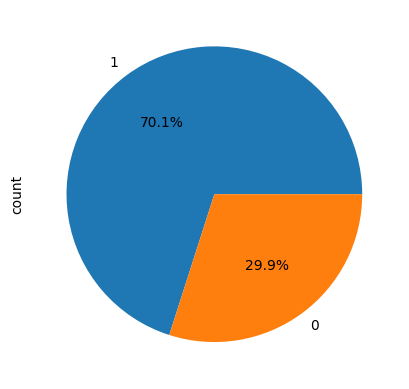

In [18]:
# Визуальное представление доли вредоносных и легитимных программ

# Подключение библиотеки для визуализации данных
import matplotlib.pyplot as plt # pyplot - интерфейс для посторения различных графиков

dataset["malware"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

## Часть 1. ПОСТРОЕНИЕ ДЕРЕВА РЕШЕНИЙ

In [19]:
# Подключение необходимых библиотек
import numpy # Математическая библиотека для работы с многомерными массивами
import pickle # Модуль для сериализации и десериализации объектов
import sklearn.ensemble as ek # Набор из двух алгоритмов рандомизированных деревьев
from sklearn.feature_selection import SelectFromModel # Метод для выбора признаков на основе их значимости
import joblib # Библиотека для параллельного выполнения задач
from sklearn.tree import DecisionTreeClassifier # Алгоритм "Дерево решений"

In [20]:
# Отбор признаков
dataset = dataset.drop(['legitimate'],axis=1)  # у нас уже есть столбец malware
dataset = dataset.drop(['Name','md5'],axis=1)   # Отброс данных признаков типа object. Модель будет принимать только признаки типа int и float

In [21]:
# Матрица признаков объектов обучающей выборки
X = dataset.drop(['malware'],axis=1).values
# Целевая переменная
y = dataset['malware'].values

In [22]:
# Разбивка данных (70% - обучающие and 30% - тестовые)

from sklearn.model_selection import train_test_split # Функция для разделения выборки на обучающую и тестовую

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.3, stratify = y)

# Алгоритмы деревьев решений и CART для задачи классификации

## 1. Общее описание дерева решений

Дерево решений — это популярный алгоритм машинного обучения, используемый как для задач **классификации**, так и для **регрессии**. В задачах классификации дерево строится в виде иерархической структуры, где каждый **внутренний узел** представляет собой проверку на значение признака, каждая **ветвь** — результат этой проверки, а каждый **листовой узел** содержит прогнозируемый класс.

### Структура дерева:
- **Корень** — верхний узел, содержащий все данные.
- **Узлы** — точки принятия решения на основе признака.
- **Листья** — конечные узлы, содержащие метки классов.

> ![Пример дерева решений](https://upload.wikimedia.org/wikipedia/commons/5/58/Decision_Tree_-_survival_of_passengers_on_the_Titanic.jpg)

*Источник: Wikimedia Commons*

---

## 2. Алгоритм CART (Classification and Regression Trees)

CART — это конкретная реализация построения дерева, разработанная Бриманом, Фридманом и др. в 1984 году. В рамках задачи **классификации** алгоритм строит бинарное дерево (каждый узел делит данные на две части).

### Основные принципы работы CART:

- **Бинарное разбиение**: в каждом узле выбирается один признак и одно пороговое значение, чтобы разделить данные на две группы.
- **Критерий качества разбиения**: используется **информационный критерий**, например:
  - **Gini impurity (индекс Джини)**: $ G = \sum_{i=1}^{C} p_i(1 - p_i) $
  - **Entropy (энтропия)**: $ H = -\sum_{i=1}^{C} p_i Log_2(p_i) $
  - **Misclassification error**: не используется в стандартном CART, т.к. менее чувствителен к изменениям.
- **Остановка роста дерева**: может происходить по достижению минимального количества образцов в узле, максимальной глубине и т.д.

---

## 3. Гиперпараметры `DecisionTreeClassifier` в `scikit-learn`

В `sklearn.tree.DecisionTreeClassifier` есть множество параметров, которые позволяют контролировать поведение и сложность модели. Ниже приведены основные:

| Параметр | Описание |
|----------|----------|
| `criterion` | Критерий для выбора лучшего разбиения (`'gini'`, `'entropy'`). |
| `max_depth` | Максимальная глубина дерева. Ограничивает количество уровней. |
| `min_samples_split` | Минимальное количество образцов в узле, необходимое для его разбиения. |
| `min_samples_leaf` | Минимальное количество образцов в листовом узле. |
| `max_features` | Количество признаков, рассматриваемых при поиске лучшего разбиения (`'sqrt'`, `'log2'`, `None`). |
| `random_state` | Фиксирует генератор случайных чисел для воспроизводимости. |
| `class_weight` | Учет дисбаланса классов (`'balanced'`, `{0: 1, 1: 5}`, `None`). |

In [23]:
# инциализация и обучение модели

model  = DecisionTreeClassifier()
model.fit(X_train, y_train) #TRAIN

DecisionTreeClassifier()

In [24]:
# визуализиурем получившееся дерево решений
!mkdir 'images'
from sklearn import tree

dotfile = open("images/tree.dot", 'w')
tree.export_graphviz(model,
                     out_file = dotfile,
                     feature_names = dataset.columns[:-1])
dotfile.close()

In [25]:
!apt install -y graphviz
!dot -Tpng images/tree.dot -o images/tree.png

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [26]:
# Получаем предсказания модели
y_true = y_test
y_predict = model.predict(X_test)

print(y_true.dtype, y_true.shape)
print(y_predict.dtype, y_predict.shape)

int64 (41415,)
int64 (41415,)


Рассчитаем метрики

## Confusion Matrix и основные метрики бинарной классификации

### Confusion Matrix (Матрица ошибок)

Confusion matrix — это таблица 2x2, которая позволяет визуализировать качество модели бинарной классификации. Она показывает количество истинных и ложных предсказаний для каждого класса.

|                     | Предсказано: НЕГАТИВНЫЙ (0) | Предсказано: ПОЗИТИВНЫЙ (1) |
|---------------------|------------------------------|------------------------------|
| **Реально: НЕГАТИВНЫЙ (0)** | True Negative (TN)           | False Positive (FP)          |
| **Реально: ПОЗИТИВНЫ | False Negative (FN)          | True Positive (TP)           |

- **True Positive (TP)**: модель правильно предсказала положительный класс.
- **True Negative (TN)**: модель правильно предсказала отрицательный класс.
- **False Positive (FP)**: модель ошибочно предсказала положительный класс (ложная тревога).
- **False Negative (FN)**: модель ошибочно предсказала отрицательный класс (пропуск события).

---

### Основные метрики

#### 1. Accuracy (Точность)
Доля правильных предсказаний среди всех.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

#### 2. Precision (Точность положительного класса)
Доля положительных предсказаний, которые оказались верными.

$$
Precision = \frac{TP}{TP + FP}
$$

#### 3. Recall (Полнота / Sensitivity)
Доля действительно положительных примеров, которые были правильно найдены.

$$
Recall = \frac{TP}{TP + FN}
$$

#### 4. F1-Score (F-мера)
Среднее гармоническое между precision и recall.

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

#### 5. Specificity (Специфичность)
Доля действительно отрицательных примеров, которые были правильно найдены.

$$
Specificity = \frac{TN}{TN + FP}
$$



### Когда какую метрику использовать?

- **Accuracy** — когда классы сбалансированы.
- **Precision** — когда важно минимизировать ложные срабатывания (например, спам-фильтр).
- **Recall** — когда важно минимизировать пропуски (например, диагностика болезни).
- **F1-Score** — когда нужно сбалансировать precision и recall.

In [27]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score as sklearn_f1_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# ============ ПРОВЕРКИ ПЕРЕМЕННЫХ ============
assert 'y_true' in globals(), "Переменная y_true не определена. Создайте массив с истинными метками."
assert 'y_predict' in globals(), "Переменная y_predict не определена. Создайте массив с предсказанными метками."
assert 'model' in globals(), "Переменная model не определена. Обучите модель перед использованием."

# ============ ПРОВЕРКА ДАННЫХ ============
assert y_true.shape == y_predict.shape, \
    f"Размерности не совпадают: y_true {y_true.shape} != y_predict {y_predict.shape}"

unique_values = np.unique(np.concatenate([y_true, y_predict]))
assert set(unique_values).issubset({0, 1}), \
    f"Метки должны содержать только 0 и 1, найдены: {unique_values}"

tp_array = ((y_true == y_predict) & (y_true==1))
tp = np.sum(tp_array)
print(f"TP={tp}")

# TODO: Заполните пропуски
tn = np.sum((y_true == y_predict) & (y_true == 0))   # True Negative
fp = np.sum((y_true != y_predict) & (y_true == 0))   # False Positive
fn = np.sum((y_true != y_predict) & (y_true == 1))   # False Negative

# TODO: Заполните пропуски
accuracy_manual  = (tp + tn) / (tp + tn + fp + fn)
precision_manual = tp / (tp + fp)
recall_manual    = tp / (tp + fn)
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)




TP=28856


In [28]:
# Проверка суммы
total = tp + tn + fp + fn
assert total == len(y_true), \
    f"Сумма элементов confusion matrix ({total}) не равна количеству примеров ({len(y_true)})"

print(f"\nВаши метрики:")
print(f"Accuracy: {accuracy_manual:.6f}")
print(f"Precision: {precision_manual:.6f}")
print(f"Recall: {recall_manual:.6f}")
print(f"F1-score: {f1_manual:.6f}")

# ============ МЕТРИКИ SKLEARN ============
print(f"\nМетрики sklearn (pos_label=1 по умолчанию):")
precision_sklearn = precision_score(y_true, y_predict)
recall_sklearn = recall_score(y_true, y_predict)
f1_sklearn = sklearn_f1_score(y_true, y_predict)
print(f"Precision: {precision_sklearn:.6f}")
print(f"Recall: {recall_sklearn:.6f}")
print(f"F1-score: {f1_sklearn:.6f}")

# ============ ВАЖНОЕ ПРЕДУПРЕЖДЕНИЕ ============
print(f"\n{'='*60}")
print("ВНИМАНИЕ: Sklearn по умолчанию считает метрики для pos_label=1")
print("Ваши формулы теперь должны считать для класса 1 (вредоносное)!")
print(f"{'='*60}\n")

# ============ ПРОВЕРКА С SKLEARN (pos_label=1) ============
print(f"Метрики sklearn для pos_label=1 (вредоносное):")
print(f"Precision: {precision_sklearn:.6f}")
print(f"Recall: {recall_sklearn:.6f}")
print(f"F1-score: {f1_sklearn:.6f}")

# ============ ASSERT СРАВНЕНИЯ ============
# Сравнение с sklearn для pos_label=1 (теперь вы считаете TP для класса 1)
assert np.isclose(precision_manual, precision_sklearn, atol=1e-10), \
    f"ОШИБКА в Precision!\n" \
    f"  Ваш результат: {precision_manual:.10f}\n" \
    f"  Sklearn (pos_label=1): {precision_sklearn:.10f}\n" \
    f"  Разница: {abs(precision_manual - precision_sklearn):.2e}\n" \
    f"  Подсказка: Precision = TP / (TP + FP), проверьте, что TP и FP соответствуют положительному классу 1"

assert np.isclose(recall_manual, recall_sklearn, atol=1e-10), \
    f"ОШИБКА в Recall!\n" \
    f"  Ваш результат: {recall_manual:.10f}\n" \
    f"  Sklearn (pos_label=1): {recall_sklearn:.10f}\n" \
    f"  Разница: {abs(recall_manual - recall_sklearn):.2e}\n" \
    f"  Подсказка: Recall = TP / (TP + FN), проверьте, что TP и FN соответствуют положительному классу 1"

assert np.isclose(f1_manual, f1_sklearn, atol=1e-10), \
    f"ОШИБКА в F1-score!\n" \
    f"  Ваш результат: {f1_manual:.10f}\n" \
    f"  Sklearn (pos_label=1): {f1_sklearn:.10f}\n" \
    f"  Разница: {abs(f1_manual - f1_sklearn):.2e}\n" \
    f"  Подсказка: F1 = 2 * (Precision * Recall) / (Precision + Recall)"

# ============ CONFUSION MATRIX ============
cm = confusion_matrix(y_true, y_predict, labels=model.classes_)

assert cm.shape == (2, 2), \
    f"Confusion matrix должна быть 2x2, получена {cm.shape}"

# Проверка элементов CM для положительного класса 1
assert tp == cm[1][1], \
    f"TP неверно! Ваш tp={tp}, в confusion_matrix[1][1]={cm[1][1]}. " \
    f"TP - правильно предсказанные вредоносные (класс 1)."

assert tn == cm[0][0], \
    f"TN неверно! Ваш tn={tn}, в confusion_matrix[0][0]={cm[0][0]}. " \
    f"TN - правильно предсказанные легитимные (класс 0)."

assert fp == cm[0][1], \
    f"FP неверно! Ваш fp={fp}, в confusion_matrix[0][1]={cm[0][1]}. " \
    f"FP - легитимные (0), ошибочно предсказанные как вредоносные (1)."

assert fn == cm[1][0], \
    f"FN неверно! Ваш fn={fn}, в confusion_matrix[1][0]={cm[1][0]}. " \
    f"FN - вредоносные (1), ошибочно предсказанные как легитимные (0)."


print("\n" + "="*60)
print("✅ ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ УСПЕШНО!")
print("Ваши метрики совпадают с sklearn (pos_label=1)")
print("="*60)


Ваши метрики:
Accuracy: 0.991452
Precision: 0.993390
Recall: 0.994417
F1-score: 0.993903

Метрики sklearn (pos_label=1 по умолчанию):
Precision: 0.993390
Recall: 0.994417
F1-score: 0.993903

ВНИМАНИЕ: Sklearn по умолчанию считает метрики для pos_label=1
Ваши формулы теперь должны считать для класса 1 (вредоносное)!

Метрики sklearn для pos_label=1 (вредоносное):
Precision: 0.993390
Recall: 0.994417
F1-score: 0.993903

✅ ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ УСПЕШНО!
Ваши метрики совпадают с sklearn (pos_label=1)



Precision-Recall Curve рассчитана успешно
  Точек на кривой: 3


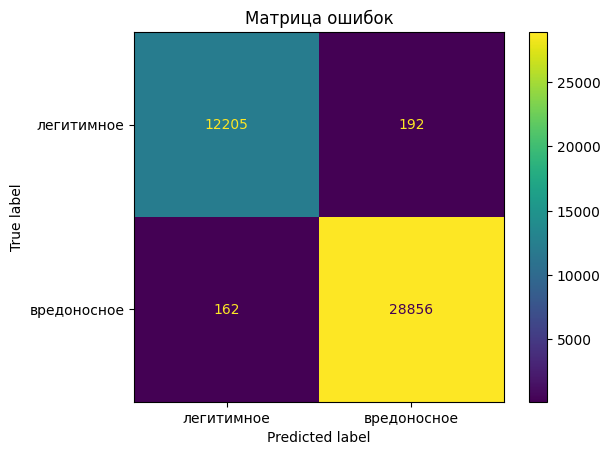

Precision: 0.993390250619664
Recall: 0.9944172582534978
f1_score: 0.9939034891330555


In [29]:
from sklearn.metrics import recall_score, precision_score, precision_recall_curve, f1_score
# ============ PRECISION-RECALL CURVE ============
try:
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_predict)
    print(f"\nPrecision-Recall Curve рассчитана успешно")
    print(f"  Точек на кривой: {len(precision_curve)}")
except Exception as e:
    print(f"\nОшибка при расчёте PR-curve: {e}")

# ============ ВИЗУАЛИЗАЦИЯ ============
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['легитимное', 'вредоносное'])
disp.plot()
plt.title('Матрица ошибок')
plt.show()


print('Precision: %s' % precision_score(y_true, y_predict))
print('Recall: %s' % recall_score(y_true, y_predict))
print('f1_score: %s' % f1_score(y_true, y_predict))


In [30]:
# сохраним модель

model_path = 'decisiontree.joblib'
from joblib import dump, load
dump(model, model_path)

['decisiontree.joblib']

ПРОВЕРЯЕМ НА РЕАЛЬНОМ ПО

In [31]:
model = load(model_path)

In [32]:
from PE_main import extract_infos

filename = 'putty.exe'
x  =  numpy.array(list(extract_infos(filename, get_entropy).values()))  # извлекаем признаки
x = x.reshape(1, -1) #массив из одного экземпляра
prediction = model.predict(x)[0]
result = 'malware' if prediction else 'legitimate'
print(result)

malware


In [ ]:
# TODO проверить на других сэмплах

## Часть 2. Выбор модели и Переобучение
### Что такое выбор модели?
* Выбор модели - как выбрать финальную модель из набора потенциальных кандидатов, основываясь на их эффективности на обучающей выборке
    * выбрать модель из множества разных типов моделей, например, из трех классов: логистическая регрессия, дерево решений или KNN(k ближайших соседей)
    * выборать модель такого же типа, но уже с другими гиперпараметрами, например, изменить глубину дерева решений
* Оценка модели - как оценить эффективность моделей-кандидатов, используя определенные метрики, например, точность

### Соображения по выбору модели
* В бизнес-проекте выбор модели - не только техническая проблема
* Существует много влияющих факторов, таких как
    * бизнес-требования
    * цена
    * эффективность
    * уровень развития
    * поддержка
* Найти **лучшую** модель очень сложно или даже невозможно. Обычно, выбирают модель, которая просто удовлетворяет требованиям
* Модель, являющаяся лучшей в плане эффективности не всегда явлется лучшей в плане бизнеса
### Параметры и гиперпараметры
* Параметры модели можно разделить на два типа:
    1. параметры - внутренние коэффициенты или веса модели
        * например, коэффициенты логистической регресии ($\beta$<sub>0</sub>, ..., $\beta$<sub>n</sub>)<br>
    $\pi = \frac{e^{\beta_{0}+\beta_{1}x_{1}+...+\beta_{n}x_{n}}}{1+e^{\beta_{0}+\beta_{1}x_{1}+...+\beta_{n}x_{n}}}$
        * полученные при подгонке модели
        * подгонка заключается в поиске оптимальных внутренних параметров модели
    2. гиперпараметры - указываются при настройке модели
        * например, глубина дерева дерений
        * подогнанные
* Подгонка гиперпараметров может значительно повысить производительность модели машинного обучения
* При ручной настройке используйте кривую точности или другие кривые для выбора наилучших гиперпараметров
* Автоматическая настройка - более мощная техника настройки гиперпараметров через их поиск
### Выборка для настройки гиперпараметров
* На тестовой выборке
    * Тестовая выборка является новыми данными для модели
    * Модель не может видеть метки классов тестовых данных.
    * Подгонять параметры на тестовой выборке невозможно
* На обучающей выборке
    * Гиперпараметры должны подгоняться на обучающей выборке
    * Однако, это плохая практика так как это ведет к переобучению
### Переобучение и недообучение

![image.png](https://wiki.loginom.ru/images/overtraining.svg)

* Переобучение
    * модель хорошо работает на тренировочной выборке
    * но плохо работает на тестовой выборке
    * например, переобучена, когда глубина дерева = 10
* Недообучение
    * модель плохо подходит к тренировочной выборке
    * и не подходит к тестовой выборке
    * например, недообучена при глубине дерева = 1


Executable and Linkable Format

In [ ]:
columns =['SectionsMaxEntropy', 'SectionsMinEntropy']
X = dataset[columns].values # Матрица признаков объектов обучающей выборки
# Целевая переменная
y = dataset['malware'].values
print(X.shape, y.shape)

In [ ]:
#!pip install --no-input prettytable
#!pip install --upgrade --no-input scikit-learn
from prettytable import PrettyTable
from sklearn.inspection import DecisionBoundaryDisplay

# Parameters
trial_n = 5 #количество попыток
train_size = 500 # маленькая выборка
n_classes = 2
plot_colors = "ryb"
plot_step = 0.02

### Пример 1: Переобучение (Сложное дерево)
* На каждом испытании из `trial_n` испытаний эксперимента
    1. создаем дерево с неограниченной глубиной  
    2. проверяем точность модели на обучающей и тестовой выборках
        - точность примерно 1 на обучающей выборке
        - точность на тестовой выборке  хуже
    3. Строим дерево
        - получаем очень сложное дерево

In [ ]:
t = PrettyTable(['Train Accuracy', 'Test Accuracy'])
plt.figure(1, figsize=(15, 3), dpi=1000)
for i in range(1, trial_n + 1 ):
    X_train, X_test, y_train, y_test = train_test_split(X, y , stratify = y,
                                                        train_size = train_size)
    model  = DecisionTreeClassifier()
    model.fit(X_train, y_train) #TRAIN
    train_score = model.score(X_train,y_train) #TEST on train dataset
    test_score = model.score(X_test,y_test)  #TEST on test dataset
    t.add_row([round(train_score, 3), round(test_score, 3)])
    #экспортируем дерево в dot file
    dotfile = open("images/tree%s.dot" % i, 'w')
    tree.export_graphviz(model,
                         out_file = dotfile,
                         feature_names = columns)
    dotfile.close()

    # Plot the decision boundary
    ax = plt.subplot(1, trial_n, i)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=columns[0],
        ylabel=columns[1],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = numpy.where(y_train == i)
        plt.scatter(
            X_train[idx, 0],
            X_train[idx, 1],
            c=color,
            label=['легитимное', 'вредоносное'][i],
            cmap=plt.cm.RdYlBu,
            edgecolor="black",
            s=15,
        )
print(t)

plt.suptitle("Поверхность принятия решения")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

plt.savefig('images/decision_border.png')

Экспорт деревье в рисунок png

In [ ]:
%%bash
for i in $(seq 1 5);
do
    dot -Tpng images/tree$i.dot -o images/tree$i.png
done

### Пример 2: Недообучение (Простое дерево)
* Ограничим размер дерева
* На каждом испытании из `trial_n` испытаний эксперимента
    1. создаем дерево с ограниченной глубиной  
    2. проверяем точность модели на обучающей и тестовой выборках
        - точность примерно 1 на
        - точность на обучающей выборке и  тестовой выборке  совападают, но ниже, чем в предыдущем примере
    3. Строим дерево
        - получаем слишком простое дерево

In [ ]:
t = PrettyTable(['Train Accuracy', 'Test Accuracy'])
plt.figure(1, figsize=(15, 3), dpi=1000)
for i in range(1, trial_n + 1 ):
    X_train, X_test, y_train, y_test = train_test_split(X, y , stratify = y,
                                                        train_size = train_size)
    model  = DecisionTreeClassifier(max_depth=2)
    model.fit(X_train, y_train) #TRAIN
    train_score = model.score(X_train,y_train) #TEST on train dataset
    test_score = model.score(X_test,y_test)  #TEST on test dataset
    t.add_row([round(train_score, 3), round(test_score, 3)])
    #экспортируем дерево в dot file
    dotfile = open("images/tree%s.dot" % i, 'w')
    tree.export_graphviz(model,
                         out_file = dotfile,
                         feature_names = columns)
    dotfile.close()

    # Plot the decision boundary
    ax = plt.subplot(1, trial_n, i)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=columns[0],
        ylabel=columns[1],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = numpy.where(y_train == i)
        plt.scatter(
            X_train[idx, 0],
            X_train[idx, 1],
            c=color,
            label=['легитимное', 'вредоносное'][i],
            cmap=plt.cm.RdYlBu,
            edgecolor="black",
            s=15,
        )
print(t)

plt.suptitle("Поверхность принятия решения")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

plt.savefig('images/decision_border.png')

In [ ]:
%%bash
for i in $(seq 1 5);
do
    dot -Tpng images/tree$i.dot -o images/tree$i.png
done

Bias-variance tradeoff

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , stratify = y,
                                                    train_size = 100000)
max_depths = numpy.arange(start=1, stop=50, step=1)
train_scores = []
test_scores = []
for max_depth in max_depths:
    model  = DecisionTreeClassifier(max_depth=max_depth)
    #TODO обучение модели на обучающем наборе
    y_train_pred =  #TODO предсказания модели на обучающем наборе
    y_test_pred =  #TODO предсказания модели на тестовом наборе
    f1_score_train = #TODO расчет метрики качества классификации (accuracy или f1 мера)на обучающем наборе
    f1_score_test= #TODO расчет метрики качества классификации (accuracy или f1 мера) на тестовом наборе
    train_scores.append(f1_score_train)
    test_scores.append(f1_score_test)

#plot
plt.plot(max_depths, train_scores)
plt.plot(max_depths, test_scores)
plt.show()

## Валидационная выборка, GridSearch/RandomSearch и Кросс-валидация

### 1. Валидационная выборка

*** Данные делятся на три части:
    - Обучающая выборка: используется для поиска наилучших внутренних параметров модели
    - Валидационная выборка: используется для выборка модели и подгонки гиперпараметров
    - Тестовая выборка: используется для оценки эффективности модели
* Выбор может отличаться в зависимости от способа разбивки выборки**

Для оценки качества модели и подбора гиперпараметров выборку данных разбивают на **обучающую (train)**, **валидационную (validation)** и **тестовую (test)**.

- **Train обучения модели.
- **Validation set**: используется для настройки гиперпараметров и выбора лучшей модели.
- **Test set**: используется для окончательной оценки производительности модели, которую не видела модель в процессе обучения/настройки.

**Цель**: избежать переобучения и получить объективную оценку обобщающей способности модели.

---

### 2. GridSearch и RandomSearch

Это методы **поиска по сетке** и **случайного поиска** по пространству гиперпараметров.

#### GridSearch
- Перебирает **все возможные комбинации** заданных гиперпараметров.
- Если пространство велико, может быть **вычислительно затратно**.

#### RandomSearch
- Выбирает **случайные комбинации** гиперпараметров из заданного распределения.
- Часто более **эффективен**, особенно при большом количестве параметров.

---

### 3. Кросс-валидация (Cross-Validation)

Кросс-валидация — это методика оценки качества модели, при которой данные разбиваются на **k частей (фолдов)**. Модель обучается на k-1 фолдах и тестируется на оставшемся фолде. Процесс повторяется k раз, и итоговая оценка — это **среднее** по всем итерациям.

#### K-Fold Cross-Validation

### k-fold кросс-валидация
* В k-fold кросс-валидации, обучающая выборка делится случайным образом на k частей без замены
    - k-1 частей используются для обучения
    - 1 часть используется для валидации
* Эта процедура повторяется k раз, так что мы получаем k моделей и оценок производительности
* Преимущества:
    - Каждый пример данных будет частью обучающей и тестовой выборки ровно один раз
    
### На сколько частей делить?

* Больше частей - больше время вычислений
* 3-fold кросс валидация - хороший выбор для очень больших объемов данных
* Поэлементная кросс валидация(leave-one-out CV) - хороший выбор для очень маленьких объемов банных
* Частый выбор
    - Много исследователей используют k=10. Такой выбор даёт хорошие результаты на большинстве данных
    
#### Пример  Построение валидационных кривых
* Выборка: набор данных по диабету
* Классификатор: дерево выборов
* Разделить данные на две части: обучающую и тестовую выборки
* Тренировочная выборка использует 5-fold кросс-валидацию
* Диапазон глубины дерева - [1,15]

- Данные разбиваются на k равных частей.
- На каждой итерации:
  - Обучение: на $ D \setminus D_i $
  - Валидация: на $ D_i $
- Итоговая метрика:
  $$
  CV = \frac{1}{k} \sum_{i=1}^{k} \text{score}(M_{-i}, D_i)
  $$
  где $ M_{-i} $ — модель, обученная без i-го фолда.

#### Преимущества:
- Более **надежная** оценка обобщающей способности.
- Полное использование данных (в отличие от hold-out).
- Позволяет оценить **стабильность** модели.

---

![img](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

---

### Заключение

- **Валидационная выборка** помогает избежать переобучения и выбрать модель.
- **GridSearch/RandomSearch** используются для подбора гиперпараметров.
- **Кросс-валидация** дает более надежную оценку качества модели, особенно при ограниченных данных.

In [ ]:
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(max_depth=16)
print(numpy.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')))

In [ ]:
model = DecisionTreeClassifier(max_depth=2)
print(numpy.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')))

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
model = DecisionTreeClassifier()

In [ ]:
parametrs = {'max_depth':[2,  8, 16], 'min_samples_leaf': [1,  4, 16,  64], 'criterion': ('gini',  "entropy", "log_loss" )}

In [ ]:
clf = GridSearchCV(model, parametrs, scoring='f1_macro', cv=3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , stratify = y,
                                                        train_size = 1000)
clf.fit(X_train, y_train)

In [ ]:
clf.best_params_

In [ ]:
clf.best_score_

## Часть 3. Ансамблевые методы: Случайный лес и Бустинг

Ансамблевые методы — это подходы в машинном обучении, которые объединяют несколько базовых моделей (обычно слабых) для создания одной сильной предиктивной модели. Основная идея заключается в том, что комбинирование множества моделей позволяет снизить общую ошибку по сравнению с использованием одной модели.

Общая формула ансамбля для задачи регрессии выглядит так:
$$ F(x) = \sum_{m=1}^{M} w_m h_m(x) $$
где $h_m(x)$ — базовая модель (weak learner), $w_m$ — её вес, $M$ — количество моделей в ансамбле.

---

## 1. Случайный лес (Random Forest)

Случайный лес основан на методе **бэггинга** (Bootstrap Aggregating) и строится на базе решающих деревьев. Главное отличие от простого бэггинга — метод случайных подпространств (Random Subspaces), который добавляет стохастичность при построении каждого дерева.

### Математическое описание
1. **Bootstrap:** Пусть имеется обучающая выборка $D$ размера $N$. Для каждого дерева $m$ генерируется новая выборка $D_m$ размера $N$ путем случайного выбора с возвращением.
   Вероятность того, что конкретный объект *не попадет* в выборку $D_m$:
   $$ P(\text{не попасть}) = Left(1 - \frac{1}{N}\right)^N \xrightarrow{N \to \infty} e^{-1} \approx 0.368 $$
   Эти 36.8% объектов называются **Out-of-Bag (OOB)** и используются для оценки ошибки без кросс-валидации.

2. **Обучение дерева:** При каждом разбиении узла дерева выбирается случайное подмножество признаков размером $m_{try}$ (обычно $\sqrt{p}$ для классификации и $p/3$ для регрессии, где $p$ — общее число признаков). Разбиение ищется только по этим признакам.

3. **Итоговое предсказание:**
   * **Регрессия:** Среднее арифметическое $$ \hat{y} = \frac{1}{M} \sum_{m=1}^{M} T_m(x) $$
   * **Классификация:** Голосование большинством $$ \hat{y} = \arg\max_{c} \sum_{m=1}^{M} \mathbb{I}(T_m(x) = c) $$

### Связь с компромиссом смещения и разброса (Bias-Variance Tradeoff)
Общая ошибка модели распадается на: $\text{Ошибка} = \text{Bias}^2 + \text{Variance} + \text{Noise}$.

* Решающие деревья имеют **низкое смещение (low bias)**, но **высокий разброс (high variance)** (они сильно подстраиваются под данные).
* Бэггинг **снижает дисперсию (variance)**. Если базовые модели некоррелированы, дисперсия ансамбля уменьшается в $M$ раз: $\text{Var}_{ensemle} = \frac{\sigma^2}{M}$.
* На практике деревья коррелированы (выделяют одинаковые важные признаки). Случайный выбор признаков ($m_{try}$) **уменьшает корреляцию между деревьями**, что дополнительно снижает дисперсию ансамбля.
* *Итог:* Случайный лес сохраняет низкое смещение дерева и радикально снижает его разброс.

### Основные классы и методы в `sklearn`
* **Классы:** `sklearn.ensemble.RandomForestClassifier`, `sklearn.ensemble.RandomForestRegressor`
* **Ключевые гиперпараметры:** `n_estimators` (число деревьев), `max_depth`, `min_samples_split`, `max_features` (аналог $m_{try}$), `bootstrap` (включение бэггинга), `oob_score` (использование OOB ошибок).
* **Методы:**
  * `.fit(X, y)` — обучение модели.
  * `.predict(X)` / `.predict_proba(X)` — предсказание классов / вероятностей.
  * `.feature_importances_` — атрибут, возвращающий важность признаков на основе среднего снижения примеси (Gini/Entropy).

---

## 2. Бустинг (Boosting)

В отличие от бэггинга, бустинг строит базовые модели **последовательно**. Каждая новая модель пытается исправить ошибки, допущенные предыдущим ансамблем. В `sklearn` основной реализацией является Градиентный бустинг (Gradient Boosting).

### Математическое описание
Бустинг решает задачу минимизации функции потерь $L(y, F(x))$ путем добавления моделей в виде градиентного спуска в функциональном пространстве.

1. **Инициализация:** Строится начальная модель $F_0(x)$, обычно это константа, минимизирующая потерю: $F_0(x) = \arg\min_{\gamma} \sum_{i=1}^N L(y_i, \gamma)$.

2. **Цикл по $m$ от 1 до $M$:**
   * Вычисляются **псевдо-остатки** (антиградиент функции потерь по предсказаниям текущей модели):
     $$ r_{im} = - [ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} ]_{F=F_{m-1}} $$
   * Обучается новое базовое дерево $h_m(x)$ на псевдо-остатках $r_{im}$.
   * Методом наименьших квадратов находится оптимальный вес (шаг) $\gamma_m$ для листьев дерева $h_m$:
     $$ \gamma_m = \arg\min_{\gamma} \sum_{i=1}^N (y_i, F_{m-1}(x_i) + \gamma h_m(x_i)) $$
   * Обновляется ансамбль:
     $$ F_m(x) = F_{m-1}(x) + \nu \cdot \gamma_m h_m(x) $$
     где $\nu \in (0, 1]$ — **learning rate** (скорость/шаг обучения).

### Связь с компромиссом смещения и разброса (Bias-Variance Tradeoff)
* В бустинге используются **очень простые деревья** (деревья-пеньки, `max_depth` = 1-3). Такие деревья имеют **высокое смещение (high bias)** и низкий разброс.
* Последовательное добавление новых деревьев, обученных на ошибках, **агрессивно снижает смещение**.
* *Проблема:* По мере уменьшения смещения, ансамбль начинает переобучаться, и **разброс (variance) начинает расти**.
* *Решение:* Гиперпараметр $\nu$ (learning rate) и ранняя остановка (early stopping) работают как регуляризаторы — они замедляют обучение, не позволяя дисперсии сильно возрасти, находя оптимальный баланс.

### Основные классы и методы в `sklearn`
* **Классы:**
  * `sklearn.ensemble.GradientBoostingClassifier` / `GradientBoostingRegressor` (Классический алгоритм Фридмана).
  * `sklearn.ensemble.HistGradientBoostingClassifier` / `HistGradientBoostingRegressor` (Современная, быстрая реализация на основе гистограмм, поддерживает пропуски `NaN`).
  * `sklearn.ensemble.AdaBoostClassifier` / `AdaBoostRegressor` (Адаптивный бустинг, меняет веса объектов, а не использует градиенты).
* **Ключевые гиперпараметры:** `n_estimators`, `learning_rate` ($\nu$), `max_depth` (обычно 3-5), `loss` (тип функции потерь: 'log_loss', 'squared_error' и др.), `subsample` (стохастический бустинг, аналог бэггинга для снижения variance).
* **Методы:**
  * `.fit(X, y)` — обучение (в `HistGradientBoosting` можно передать `validation_set` для early stopping).
  * `.predict(X)` / `.predict_proba(X)` — предсказание.
  * `.staged_predict(X)` — генератор предсказаний ансамбля на каждой итерации (полезно для анализа кривой обучения).
  * `.feature_importances_` — важность признаков.

---

## Краткое сравнение

| Характеристика | Случайный лес (Random Forest) | Бустинг (Boosting) |
| :--- | :--- | :--- |
| **Обучение моделей** | Параллельно (независимо) | Последовательно (цепочка) |
| **Базовая модель** | Глубокие деревья (Low Bias) | Поверхностные деревья (High Bias) |
| **Основной эффект** | Снижение **Variance** (Разброса) | Снижение **Bias** (Смещения) |
| **Устойчивость к переобучению** | Высокая (можно ставить много деревьев) | Низкая (нужна регуляризация и early stopping) |
| **Чувствительность к выбросам** | Умеренная | Высокая (из-за градиентов на больших ошибках) |

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , stratify = y,
                                                    train_size = 1000)

In [ ]:
model = RandomForestClassifier()

In [ ]:
parametrs = {'max_depth':[8, 16, 32], 'min_samples_leaf': [1,  4, 16,  64], 'criterion': ('gini',  "entropy", "log_loss" )}

In [ ]:
clf = GridSearchCV(model, parametrs, scoring='f1_macro', cv=3)

In [ ]:
clf.fit(X_train, y_train)

In [ ]:
clf.best_params_, clf.best_score_

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
model = GradientBoostingClassifier()

In [ ]:
parametrs = {'max_depth':[2, 4, 8, 16, 32], 'min_samples_leaf': [1,  4, 16,  64]}

In [ ]:
clf = GridSearchCV(model, parametrs, scoring='f1_macro', cv=3)

In [ ]:
clf.fit(X_train, y_train)

In [ ]:
clf.best_params_, clf.best_score_